In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

print("Searching for TIFF and weight files...\n")

patterns = [
    "rgb3_alpha_native.tif",
    "dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth",
    "dinov3_vitl16_chmv2_dpt_head-3703d643.pth",
]

for pattern in patterns:
    print(f"--- Searching for: {pattern} ---")
    matches = list(drive_root.rglob(pattern))
    if matches:
        for m in matches:
            print(m)
    else:
        print("Not found")
    print()


Searching for TIFF and weight files...

--- Searching for: rgb3_alpha_native.tif ---
/content/drive/MyDrive/electric-pole-analysi/inputs/rgb3_alpha_native.tif

--- Searching for: dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth ---
/content/drive/MyDrive/electric-pole-analysi/weights/chmv2/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth

--- Searching for: dinov3_vitl16_chmv2_dpt_head-3703d643.pth ---
/content/drive/MyDrive/electric-pole-analysi/weights/chmv2/dinov3_vitl16_chmv2_dpt_head-3703d643.pth



In [ ]:
from pathlib import Path

input_path = Path("/content/drive/MyDrive/electric-pole-analysi/inputs/rgb3_alpha_native.tif")
backbone_weights = Path("/content/drive/MyDrive/electric-pole-analysi/weights/chmv2/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth")
chmv2_weights = Path("/content/drive/MyDrive/electric-pole-analysi/weights/chmv2/dinov3_vitl16_chmv2_dpt_head-3703d643.pth")

output_dir = Path("/content/drive/MyDrive/electric-pole-analysis/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

print("Input exists:", input_path.exists())
print("Backbone exists:", backbone_weights.exists())
print("CHMv2 head exists:", chmv2_weights.exists())
print("Output dir:", output_dir)


Input exists: True
Backbone exists: True
CHMv2 head exists: True
Output dir: /content/drive/MyDrive/electric-pole-analysis/outputs


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
Device count: 1
GPU: Tesla T4


In [ ]:
!git clone https://github.com/facebookresearch/dinov3.git /content/dinov3


Cloning into '/content/dinov3'...
remote: Enumerating objects: 579, done.
remote: Counting objects: 100% (445/445), done.
remote: Compressing objects: 100% (337/337), done.
remote: Total 579 (delta 234), reused 108 (delta 108), pack-reused 134 (from 2)
Receiving objects: 100% (579/579), 12.44 MiB | 13.49 MiB/s, done.
Resolving deltas: 100% (248/248), done.


In [ ]:
!pip install -q rasterio shapely tqdm


In [ ]:
!pip install -q torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 54.5 MB/s eta 0:00:00


In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt

import rasterio
from rasterio.windows import Window

import torch
import torch.nn.functional as F
from torchvision.transforms import v2
from tqdm.notebook import tqdm
from pathlib import Path


In [ ]:
dinov3_repo_dir = Path("/content/dinov3")

if str(dinov3_repo_dir) not in sys.path:
    sys.path.append(str(dinov3_repo_dir))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

chmv2_model = torch.hub.load(
    str(dinov3_repo_dir),
    "dinov3_vitl16_chmv2",
    source="local",
    weights=str(chmv2_weights),
    backbone_weights=str(backbone_weights),
)
chmv2_model.to(device).eval()

print("CHMv2 model loaded")


Device: cuda
Downloading: "file:///content/drive/MyDrive/electric-pole-analysi/weights/chmv2/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth" to /root/.cache/torch/hub/checkpoints/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth


100%|██████████| 1.13G/1.13G [00:31<00:00, 39.0MB/s]


Downloading: "file:///content/drive/MyDrive/electric-pole-analysi/weights/chmv2/dinov3_vitl16_chmv2_dpt_head-3703d643.pth" to /root/.cache/torch/hub/checkpoints/dinov3_vitl16_chmv2_dpt_head-3703d643.pth


100%|██████████| 129M/129M [00:12<00:00, 10.6MB/s]

CHMv2 model loaded


In [ ]:
def compute_starts(length: int, tile_size: int, overlap: int) -> list[int]:
    if length <= tile_size:
        return [0]

    step = tile_size - overlap
    starts = list(range(0, length - tile_size + 1, step))
    if starts[-1] != length - tile_size:
        starts.append(length - tile_size)
    return starts


def make_axis_blend(length: int, overlap: int, pin_start: bool, pin_end: bool) -> np.ndarray:
    weights = np.ones(length, dtype=np.float32)
    if overlap <= 0 or length <= 1:
        return weights

    fade = min(overlap, max(1, length // 2))
    edge_floor = 1.0 / (fade + 1)

    if not pin_start:
        weights[:fade] = np.linspace(edge_floor, 1.0, fade, dtype=np.float32)
    if not pin_end:
        weights[-fade:] = np.minimum(weights[-fade:], np.linspace(1.0, edge_floor, fade, dtype=np.float32))
    return weights


def make_blend_mask(tile_height: int, tile_width: int, overlap: int, at_top: bool, at_bottom: bool, at_left: bool, at_right: bool) -> np.ndarray:
    row_weights = make_axis_blend(tile_height, overlap, pin_start=at_top, pin_end=at_bottom)
    col_weights = make_axis_blend(tile_width, overlap, pin_start=at_left, pin_end=at_right)
    return np.outer(row_weights, col_weights).astype(np.float32)


def predict_tile(tile: np.ndarray) -> np.ndarray:
    tile_tensor = torch.from_numpy(tile)
    tile_processed = image_transform(tile_tensor).unsqueeze(0).to(device)

    with torch.inference_mode():
        pred = chmv2_model(tile_processed)
        pred = F.interpolate(pred, size=tile.shape[-2:], mode="bilinear", align_corners=False)

    return pred.squeeze().detach().cpu().to(torch.float32).numpy()


In [ ]:
# Start with a practical default
TILE_SIZE = 512
OVERLAP = 64

print("TILE_SIZE:", TILE_SIZE)
print("OVERLAP:", OVERLAP)


TILE_SIZE: 512
OVERLAP: 64


In [ ]:
CHMV2_MEAN = (0.420, 0.411, 0.296)
CHMV2_STD = (0.213, 0.156, 0.143)

image_transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=CHMV2_MEAN, std=CHMV2_STD),
    ]
)

print("Transform ready")


Transform ready


In [ ]:
output_chm_path = output_dir / f"chmv2_minimal_tile{TILE_SIZE}_ov{OVERLAP}.tif"

with rasterio.open(input_path) as src:
    profile = src.profile.copy()
    height = src.height
    width = src.width
    rgb_preview = src.read([1, 2, 3])
    valid_mask = src.read_masks(1) > 0

    row_starts = compute_starts(height, TILE_SIZE, OVERLAP)
    col_starts = compute_starts(width, TILE_SIZE, OVERLAP)

    prediction_sum = np.zeros((height, width), dtype=np.float32)
    prediction_weight = np.zeros((height, width), dtype=np.float32)

    total_tiles = len(row_starts) * len(col_starts)
    print("Total tiles:", total_tiles)

    for row_idx, row_start in enumerate(tqdm(row_starts, desc="row tiles")):
        for col_idx, col_start in enumerate(col_starts):
            window_height = min(TILE_SIZE, height - row_start)
            window_width = min(TILE_SIZE, width - col_start)
            window = Window(col_off=col_start, row_off=row_start, width=window_width, height=window_height)

            tile = src.read([1, 2, 3], window=window)
            tile_prediction = predict_tile(tile)

            blend_mask = make_blend_mask(
                tile_height=window_height,
                tile_width=window_width,
                overlap=OVERLAP,
                at_top=row_idx == 0,
                at_bottom=row_idx == len(row_starts) - 1,
                at_left=col_idx == 0,
                at_right=col_idx == len(col_starts) - 1,
            )

            row_end = row_start + window_height
            col_end = col_start + window_width

            prediction_sum[row_start:row_end, col_start:col_end] += tile_prediction * blend_mask
            prediction_weight[row_start:row_end, col_start:col_end] += blend_mask

canopy_height = prediction_sum / prediction_weight
canopy_height[~valid_mask] = np.nan

print("Inference complete")


Total tiles: 42


row tiles:   0%|          | 0/7 [00:00<?, ?it/s]

Inference complete


In [ ]:
with rasterio.open(input_path) as src:
    profile = src.profile.copy()

profile.update({
    "count": 1,
    "dtype": "float32",
    "nodata": np.nan,
})

with rasterio.open(output_chm_path, "w", **profile) as dst:
    dst.write(canopy_height.astype(np.float32), 1)
    dst.write_mask((np.isfinite(canopy_height).astype(np.uint8) * 255))

print("Saved:", output_chm_path)


Saved: /content/drive/MyDrive/electric-pole-analysis/outputs/chmv2_minimal_tile512_ov64.tif


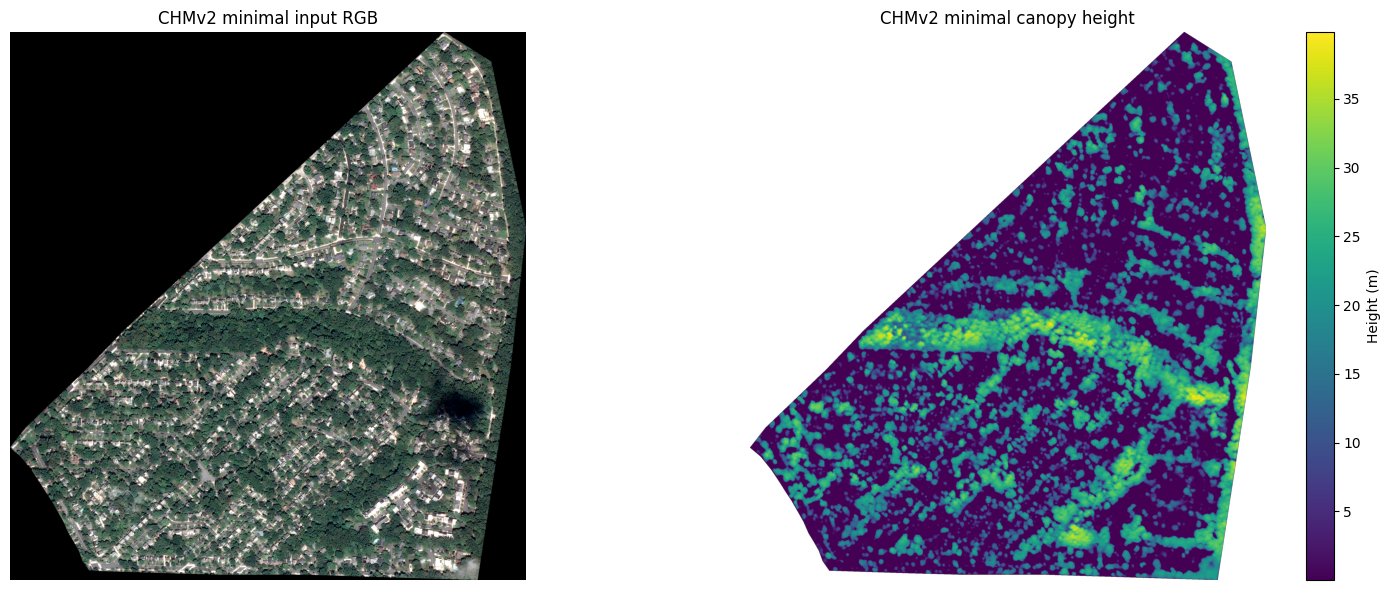

In [ ]:
rgb = np.moveaxis(rgb_preview, 0, -1)
rgb_disp = rgb.astype(np.float32).copy()

for b in range(3):
    valid = rgb_disp[..., b] > 0
    if valid.any():
        p2, p98 = np.percentile(rgb_disp[..., b][valid], (2, 98))
        if p98 > p2:
            rgb_disp[..., b] = np.clip((rgb_disp[..., b] - p2) / (p98 - p2), 0, 1)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_disp)
plt.title("CHMv2 minimal input RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(canopy_height, cmap="viridis")
plt.title("CHMv2 minimal canopy height")
plt.colorbar(label="Height (m)")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
valid = np.isfinite(canopy_height)

print("Total pixels:", canopy_height.size)
print("Valid pixels:", int(valid.sum()))
print("Invalid pixels:", int((~valid).sum()))
print("Min height:", float(np.nanmin(canopy_height)))
print("Max height:", float(np.nanmax(canopy_height)))
print("Mean height:", float(np.nanmean(canopy_height)))
print("Median height:", float(np.nanmedian(canopy_height)))
print("Std height:", float(np.nanstd(canopy_height)))


Total pixels: 7359072
Valid pixels: 4530224
Invalid pixels: 2828848
Min height: 0.009800031781196594
Max height: 39.84352493286133
Mean height: 8.596077919006348
Median height: 2.0841517448425293
Std height: 10.096405029296875


In [ ]:
percentiles = [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]
vals = np.nanpercentile(canopy_height, percentiles)

for p, v in zip(percentiles, vals):
    print(f"{p:>3}th percentile: {v:.3f} m")


  0th percentile: 0.010 m
  1th percentile: 0.011 m
  5th percentile: 0.015 m
 10th percentile: 0.020 m
 25th percentile: 0.052 m
 50th percentile: 2.084 m
 75th percentile: 17.646 m
 90th percentile: 24.080 m
 95th percentile: 27.026 m
 99th percentile: 31.682 m
100th percentile: 39.844 m
